### Assignment-1

In [ ]:
## Load the Preprocessed Dataset Here

In [7]:
# Import required libraries
import pandas as pd

# Load the preprocessed dataset
# (Change the file path to where your preprocessed CSV is stored)
df = pd.read_csv(r"C:\Users\Prasad\impactsenseAI-Infosys-Intern-project\data\preprocessed_earthquake_data.csv")


# Display basic info
print("✅ Dataset Loaded Successfully!")
print("Shape of data:", df.shape)
print("\nPreview of Data:")
display(df.head())


✅ Dataset Loaded Successfully!
Shape of data: (109848, 15)

Preview of Data:


,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,Second,DayOfWeek
0,41.758,23.249,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,10,26,0,0
1,41.802,23.108,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,10,2,34,0
2,52.763,160.277,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,21,0,38,5
3,51.424,161.638,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,14,45,39,5
4,30.684,100.608,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,11,43,20,1


Q1. Analyze the distribution of earthquake magnitudes (mag) and explore how they vary across different earthquake types (type) using visualizations such as boxplots or violin plots.

In [ ]:
!pip install seaborn

C:\Users\Prasad\AppData\Local\Temp\ipykernel_20952\3436035489.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='mag', data=df, palette='Set2')


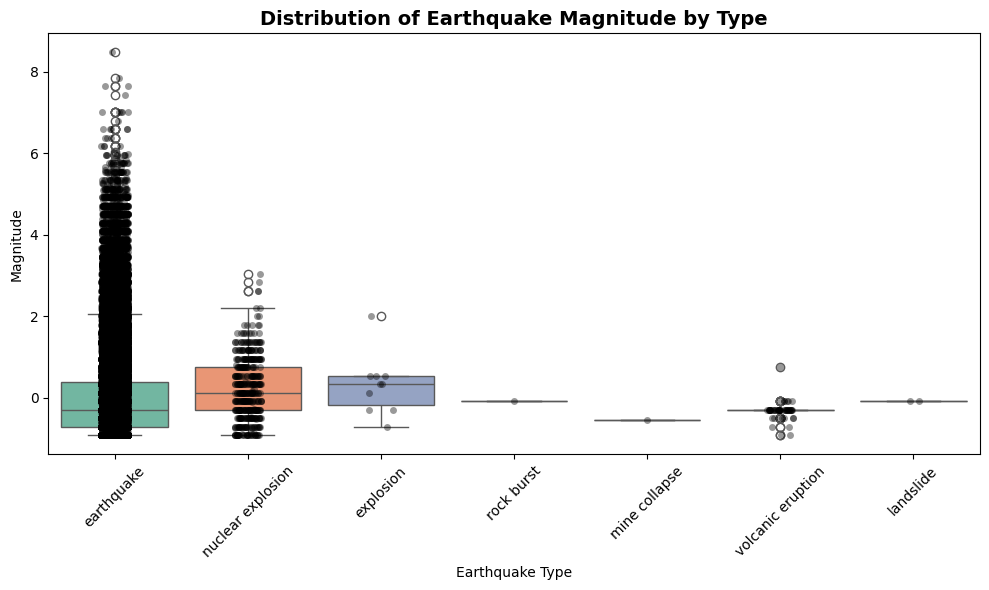

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\Prasad\impactsenseAI-Infosys-Intern-project\data\preprocessed_earthquake_data.csv")


# Drop missing values if any
df = df.dropna(subset=['mag', 'type'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='mag', data=df, palette='Set2')
sns.stripplot(x='type', y='mag', data=df, color='black', alpha=0.4)
plt.title('Distribution of Earthquake Magnitude by Type', fontsize=14, weight='bold')
plt.xlabel('Earthquake Type')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Q2. Explore the relationship between earthquake depth (depth) and magnitude (mag). Is there a trend or correlation between these two features in the dataset?

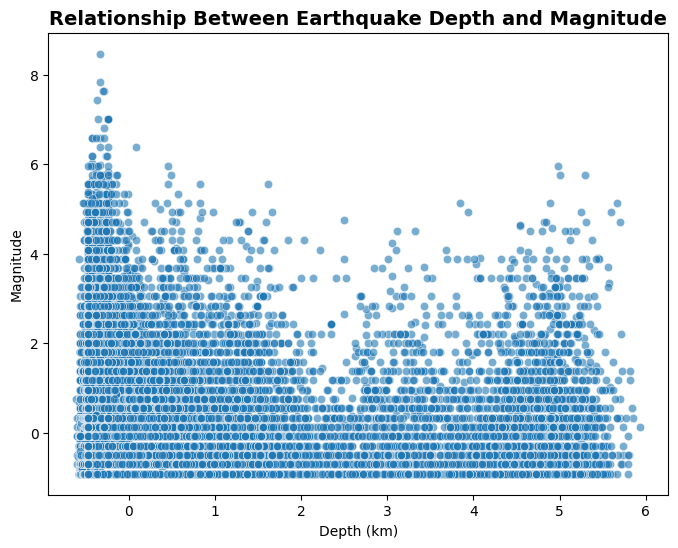

Correlation between depth and magnitude: -0.010


In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='depth', y='mag', data=df, alpha=0.6)
plt.title('Relationship Between Earthquake Depth and Magnitude', fontsize=14, weight='bold')
plt.xlabel('Depth (km)')
plt.ylabel('Magnitude')
plt.show()

# Correlation
corr = df['depth'].corr(df['mag'])
print(f"Correlation between depth and magnitude: {corr:.3f}")


Q3. Using the preprocessed temporal features (Year, Month, Day, Hour), investigate if there is any difference in earthquake frequency or magnitude over months or years. Visualize temporal trends clearly.

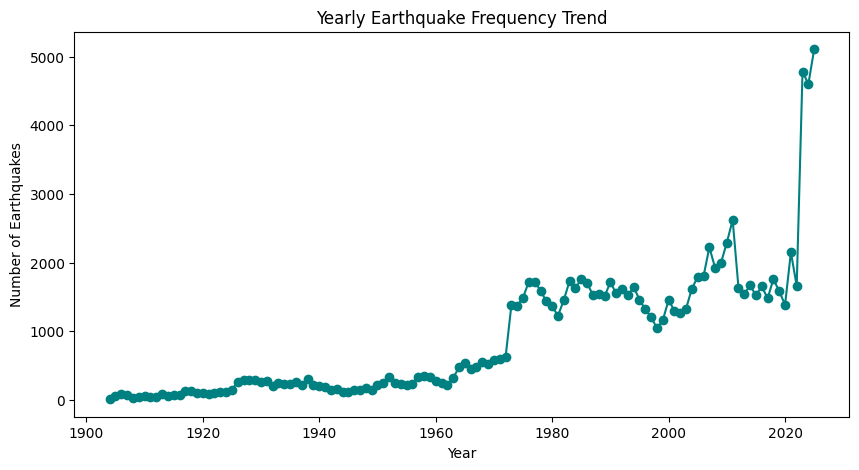

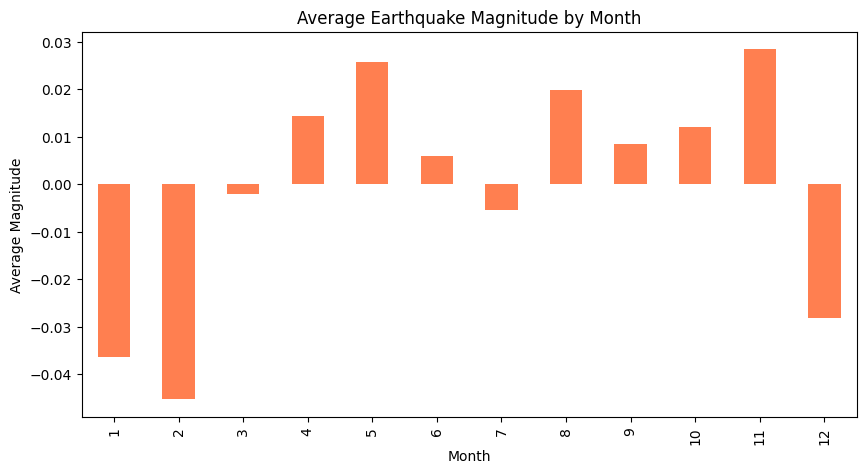

In [11]:
# Yearly trend
yearly_counts = df.groupby('Year')['mag'].count()
plt.figure(figsize=(10,5))
yearly_counts.plot(kind='line', color='teal', marker='o')
plt.title('Yearly Earthquake Frequency Trend')
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.show()

# Monthly average magnitude
monthly_mag = df.groupby('Month')['mag'].mean()
plt.figure(figsize=(10,5))
monthly_mag.plot(kind='bar', color='coral')
plt.title('Average Earthquake Magnitude by Month')
plt.xlabel('Month')
plt.ylabel('Average Magnitude')
plt.show()


Q4. Identify the most active geographical earthquake regions by plotting earthquake locations (latitude and longitude) on a map with color coding or size scaled by earthquake magnitude.

In [ ]:
!pip install geopandas

In [ ]:
!pip install geodatasets


<Figure size 1400x700 with 0 Axes>

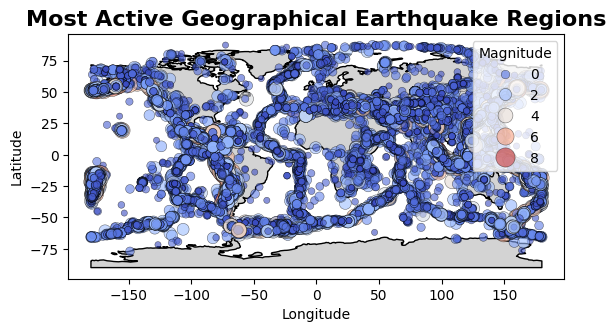

In [17]:
# Import required libraries
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed earthquake dataset
df = pd.read_csv("C:/Users/Prasad/impactsenseAI-Infosys-Intern-project/data/preprocessed_earthquake_data.csv")

# Load world map data
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))

# Plot world map
plt.figure(figsize=(14, 7))
world.plot(color='lightgray', edgecolor='black')

# Scatter plot of earthquake locations
sns.scatterplot(
    x='longitude', y='latitude', 
    data=df,
    hue='mag',           # Color based on magnitude
    size='mag',          # Size based on magnitude
    palette='coolwarm',  # Color theme
    sizes=(20, 200),     # Control the size of circles
    alpha=0.6,           # Transparency for clarity
    edgecolor='k'
)

# Add title and labels
plt.title("Most Active Geographical Earthquake Regions", fontsize=16, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Magnitude", loc='upper right')
plt.show()
